# Data Preparation & Datastore Architecture

Neural‑LAM is designed to support diverse meteorological datasets. This tutorial explains the core `Datastore` architecture, configuration, and the preprocessing steps required to prepare your data for training.

## 1. Understanding the Datastore Architecture

`BaseDatastore` provides a standardized interface for loading, stacking, and standardizing weather variables.

### Core Classes
- **`BaseDatastore`**: The abstract base class defining the interface (`get_dataarray`, `get_vars_names`, etc.).
- **`BaseRegularGridDatastore`**: Extends the base class for data on regular latitude-longitude or rotated pole grids.
- **`MDPDatastore`**: The primary implementation for handling multi-variable datasets (like ERA5 or DANRA) stored in Zarr format. It manages the "feature dimension" (stacking u/v/t/q into a single vector).

## 2. YAML Configuration Explained

The datastore is configured via a YAML file. This enables reproducible experiments without changing code.

In [1]:
import yaml
from pathlib import Path

config_path = Path('/home/sharkyi/neural-lam/data/meps_example/meps.datastore.yaml').resolve()

with open(config_path, 'r') as f:
    config_data = yaml.safe_load(f)
    print(f"Datastore Name: {config_data.get('dataset', {}).get('name')}")
    print(f"Variables: {config_data.get('dataset', {}).get('var_names')}")


Datastore Name: meps_example
Variables: ['pres_0g', 'pres_0s', 'nlwrs_0', 'nswrs_0', 'r_2', 'r_65', 't_2', 't_65', 't_500', 't_850', 'u_65', 'u_850', 'v_65', 'v_850', 'wvint_0', 'z_1000', 'z_500']


### Key Configuration Fields
- `root_path`: Where the raw/zarr data is stored.
- `variables`: Defines which variables are 'state' (prognostic) vs 'forcing' (external).
- `splits`: Defines time ranges for training, validation, and testing.

## 3. Initializing and loading data

We use `init_datastore` to load the appropriate class based on the `kind` parameter.

In [2]:
from neural_lam.datastore import init_datastore

datastore = init_datastore(datastore_kind='npyfilesmeps', config_path=str(config_path))

da_state = datastore.get_dataarray(category='state', split='train', standardize=False)

print(f"DataArray Dimensions: {da_state.dims}")
print(f"Number of features: {da_state.shape[da_state.dims.index('state_feature')]}")


/home/sharkyi/neural-lam/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DataArray Dimensions: ('analysis_time', 'elapsed_forecast_duration', 'ensemble_member', 'grid_index', 'state_feature')
Number of features: 17


## 4. Standardization

Neural networks perform best when inputs are standardized (mean=0, std=1).

### Pre-computing Statistics
The repo includes scripts like `compute_standardization_stats.py` to calculate these values across the entire training split of your dataset.

In [3]:
# Load standardized data
da_std = datastore.get_dataarray(category='state', split='train', standardize=True)

# This only compute stats on a small subset (e.g., first 5 analysis times) 
da_subset = da_std.isel(analysis_time=slice(0, 5))

print(f"  Mean: {da_subset.mean().values:.4f}")

  Mean: -0.0076


## 5. Visualization with Unstacking

Neural‑LAM processes data as a 1D sequence of graph nodes. To visualize it as a map, we use `unstack_grid_coords`.

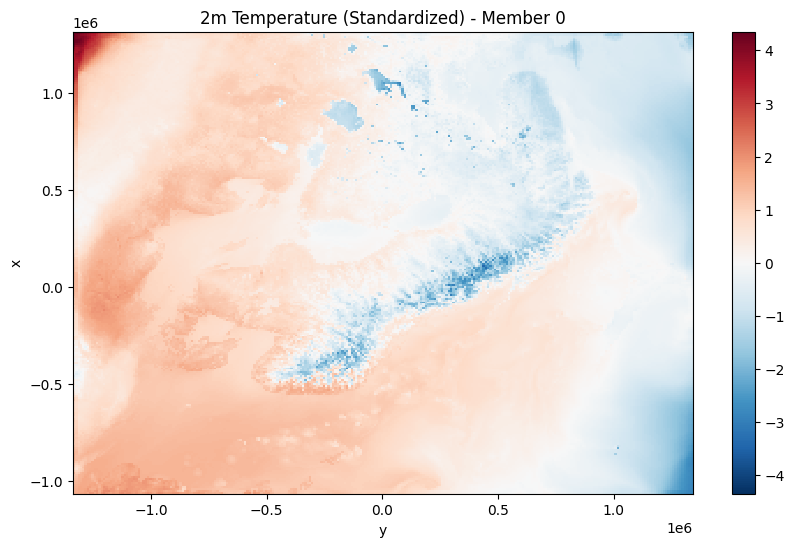

In [4]:
import matplotlib.pyplot as plt

# Fix: MEPS is an ensemble dataset, so we must select one member (e.g., ensemble_member=0)
# to get a strictly 2D array for the map plot.
sample = da_std.isel(
    analysis_time=0, 
    elapsed_forecast_duration=0, 
    ensemble_member=0
).sel(state_feature='t_2')

# Unstack 1D nodes back to the 2D (x, y) grid
grid_2d = datastore.unstack_grid_coords(sample)

plt.figure(figsize=(10, 6))
# Now that grid_2d is 2D, .plot() will correctly create a map
grid_2d.plot(cmap='RdBu_r')
plt.title("2m Temperature (Standardized) - Member 0")
plt.show()
